### NAME : **THIRUMALAI K**     
### REG_NO : **212224240176**

# Coin Detection using Morphological Operations and Thresholding

## STEP : 1 READ IMAGE

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
image = cv2.imread("CoinsA.png")

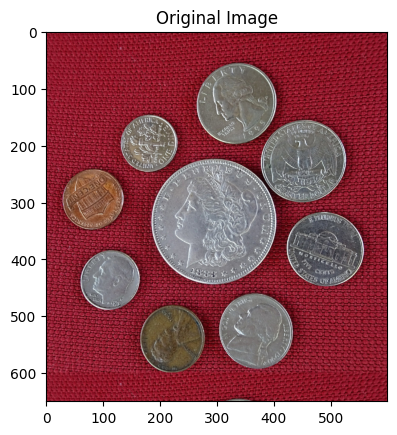

In [3]:
imageCopy = image.copy()
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")
plt.show()

## STEP 2 : CONVERT GRAYSCALE IMAGE

In [4]:
imageGray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)


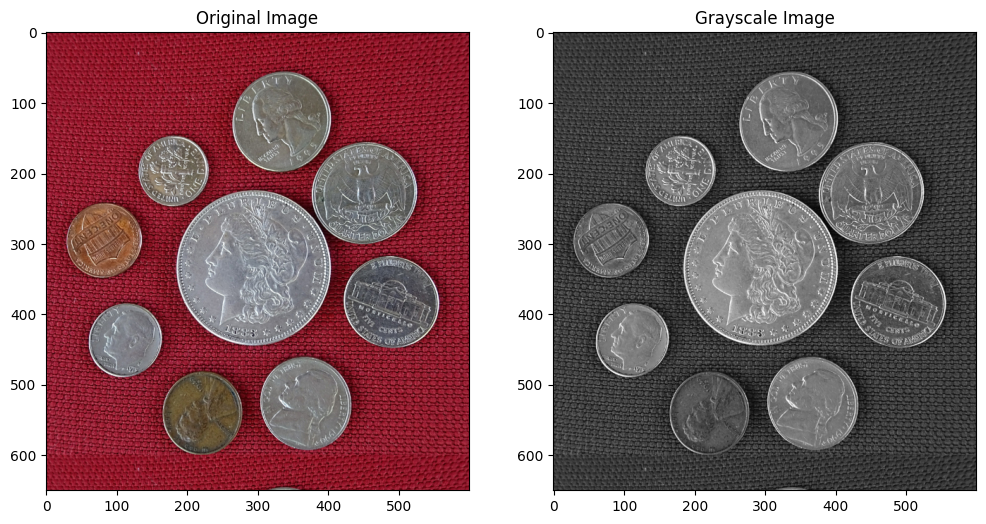

In [5]:
plt.figure(figsize=(12,12))
plt.subplot(121);plt.imshow(image[:,:,::-1]);plt.title("Original Image")
plt.subplot(122); plt.imshow(imageGray,cmap='gray');plt.title("Grayscale Image"); plt.show()

## STEP 3 : SPLIT IMAGE INTO R,G,B

In [6]:
imageB,imageG,imageR = cv2.split(image)

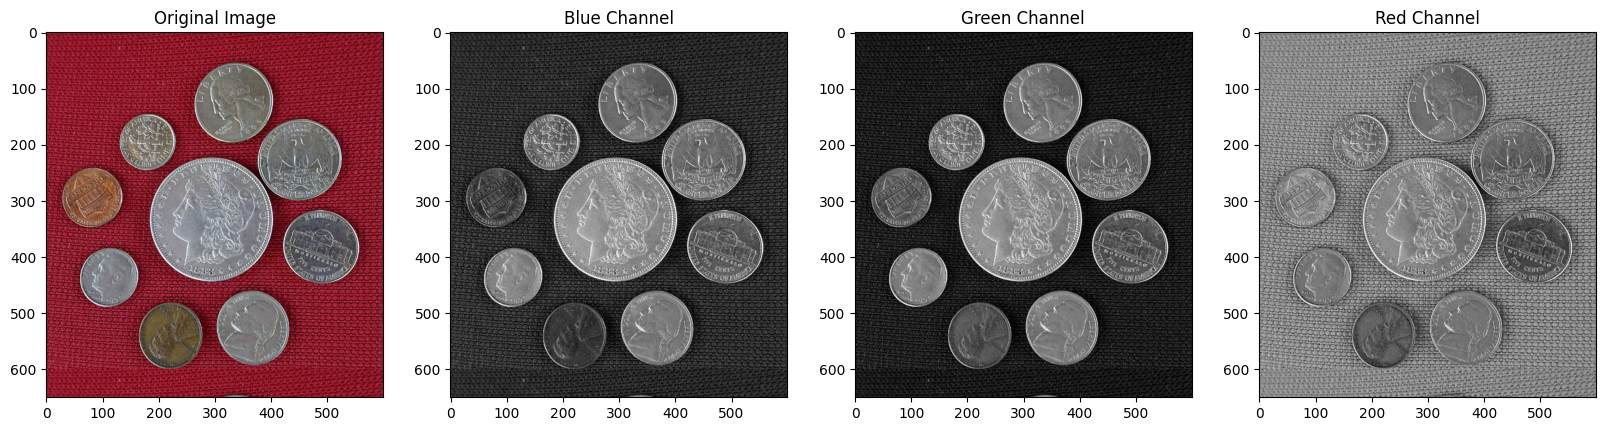

In [7]:
plt.figure(figsize=(20,12))
plt.subplot(141);plt.imshow(image[:,:,::-1]);plt.title("Original Image")
plt.subplot(142);plt.imshow(imageB,cmap='gray');plt.title("Blue Channel")
plt.subplot(143);plt.imshow(imageG,cmap='gray');plt.title("Green Channel")
plt.subplot(144);plt.imshow(imageR,cmap='gray');plt.title("Red Channel");
plt.show()

## STEP 4 : PERFORM THRESHOLDING

(np.float64(-0.5), np.float64(599.5), np.float64(649.5), np.float64(-0.5))

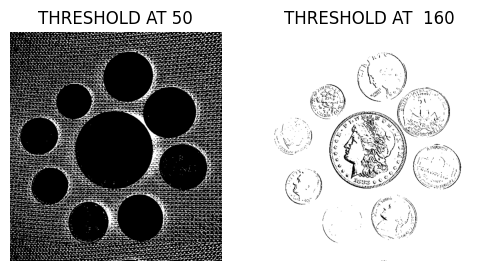

In [108]:
ret, threshold = cv2.threshold(
    imageGray,
    48,
    255,
    cv2.THRESH_BINARY_INV
)

ret1,threshold1 = cv2.threshold(
    imageGray,
    160,
    255,
    cv2.THRESH_BINARY_INV
)

plt.figure(figsize=(6,12))
plt.subplot(121);plt.imshow(threshold,cmap="gray");plt.title("THRESHOLD AT 50");plt.axis("off")
plt.subplot(122);plt.imshow(threshold1,cmap='gray');plt.title("THRESHOLD AT  160");plt.axis("off")

## PERFORM MORPHOLOGICAL OPERATION

In [149]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

In [150]:
imageDilated1 = cv2.dilate(
    threshold,
    kernel,
    iterations = 1
)

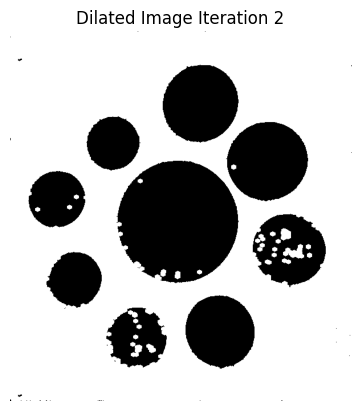

In [151]:
imageDilated2 = cv2.dilate(
    imageDilated1,
    kernel,
    iterations = 1
)

plt.imshow(imageDilated2,cmap='gray')

plt.title('Dilated Image Iteration 2')

plt.axis("off")

plt.show()

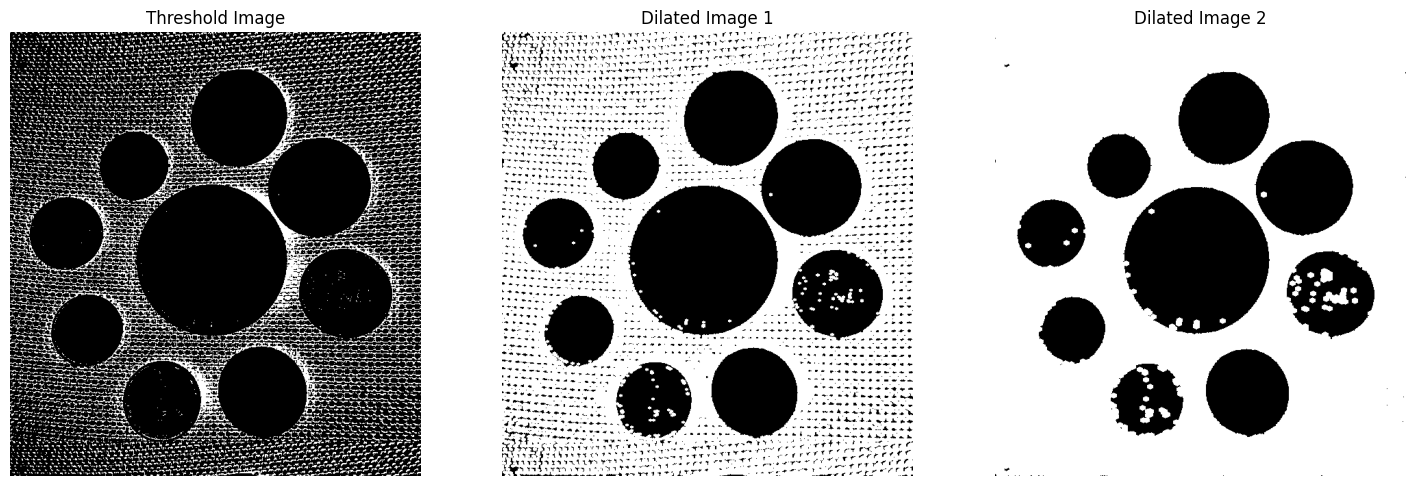

In [152]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(threshold,cmap='gray')
plt.title("Threshold Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imageDilated1,cmap='gray')
plt.title("Dilated Image 1")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(imageDilated2,cmap='gray')
plt.title("Dilated Image 2")
plt.axis("off")

plt.show()

In [153]:
kernel2 = np.ones((3,3),dtype=np.uint8)

In [154]:
imageEroded = cv2.erode(
    imageDilated2,
    kernel2,
    iterations = 1
)

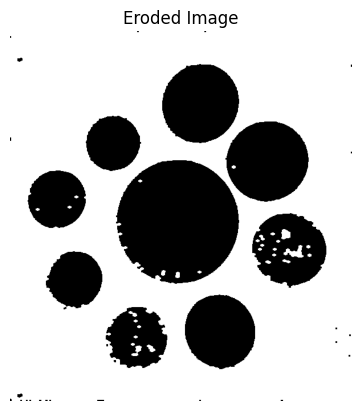

In [155]:
plt.imshow(imageEroded,cmap='gray')

plt.title("Eroded Image")

plt.axis("off")

plt.show()

In [156]:
# Set up the SimpleBlobdetector with default parameters.
params = cv2.SimpleBlobDetector_Params()

params.blobColor = 0

params.minDistBetweenBlobs = 2

# Filter by Area.
params.filterByArea = False

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.8

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.8

# Filter by Inertia
params.filterByInertia =True
params.minInertiaRatio = 0.8

In [157]:
detector = cv2.SimpleBlobDetector_create(params)

In [158]:
keypoints = detector.detect(imageEroded)

In [159]:
print("Number of Coins Detected is",len(keypoints))

Number of Coins Detected is 9
